In [2]:
import pandas as pd

In [4]:
# path to the dataset csv

data_path = "/Users/cy/Documents/Data Science & AI/Python/Projects/twitter trend analysis/data/training.1600000.processed.noemoticon.csv"

In [12]:
# Load the data (latin-1 encoding avoids errors)

df = pd.read_csv(data_path, encoding='latin-1', header=None)

df.columns = ['target', 'id', 'date', 'flag', 'user', 'text']

In [30]:
df.sample(10)

,target,id,date,flag,user,text,clean_text
1405939,4,2055273850,Sat Jun 06 09:01:13 PDT 2009,NO_QUERY,freeman1993,@simplycharis Gramo dun even have ATFU ... I w...,gramo dun even have atfu i was arranging the d...
1529395,4,2177561978,Mon Jun 15 06:19:22 PDT 2009,NO_QUERY,zuckerpueppi43,test was ok. now relaxing with a cup of coffee,test was ok now relaxing with a cup of coffee
412180,0,2060285932,Sat Jun 06 18:37:06 PDT 2009,NO_QUERY,torrez,@miconian It's a Michael Cohn fanclub.,its a michael cohn fanclub
809794,4,1469587585,Tue Apr 07 06:49:51 PDT 2009,NO_QUERY,dsalea,@vickerini you could always walk - it looks li...,you could always walk it looks like a lovely d...
719033,0,2260476717,Sat Jun 20 19:16:46 PDT 2009,NO_QUERY,kisses4rmkurls,Watching hancock the said part is coming on,watching hancock the said part is coming on
697452,0,2253820355,Sat Jun 20 08:47:37 PDT 2009,NO_QUERY,monkey1980,No new phone for me today it seems,no new phone for me today it seems
788041,0,2325043402,Thu Jun 25 04:38:27 PDT 2009,NO_QUERY,NeilJenkins65,@Wossy What happened to Sasha BC?,what happened to sasha bc
148118,0,1883015959,Fri May 22 07:52:11 PDT 2009,NO_QUERY,blonde_terror,something random: I live in Charlottesville bu...,something random i live in charlottesville but...
274350,0,1990583998,Mon Jun 01 05:15:01 PDT 2009,NO_QUERY,whit2fresh,on my way to the doctor,on my way to the doctor
1319765,4,2014511340,Wed Jun 03 01:46:39 PDT 2009,NO_QUERY,_mishhh,"@nna_aka_ann [2nd time lucky] IF YOU SEE THIS,...",nd time lucky if you see this twitter back


In [22]:
# Check sentiment (i.e. target column) class distribution

df['target'].value_counts()

target
0    800000
4    800000
Name: count, dtype: int64

In [26]:
import re    #regular expressions

def clean_tweet(text):
    text = text.lower()                            # Convert to lowercase
    text = re.sub(r'@\w+', '', text)               # Remove mentions like @username
    text = re.sub(r'http\S+', '', text)            # Remove URLs (http or https)
    text = re.sub(r'[^a-z\s]', '', text)           # Remove punctuation, numbers, emojis, symbols
    text = re.sub(r'\s+', ' ', text).strip()       # Normalize spaces: remove extras and trim edges
    return text

# Apply to the text column
df['clean_text'] = df['text'].apply(clean_tweet)

# Show some cleaned tweets
df[['text', 'clean_text']].head(10)

,text,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww thats a bummer you shoulda got david carr...
1,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...
5,@Kwesidei not the whole crew,not the whole crew
6,Need a hug,need a hug
7,@LOLTrish hey long time no see! Yes.. Rains a...,hey long time no see yes rains a bit only a bi...
8,@Tatiana_K nope they didn't have it,nope they didnt have it
9,@twittera que me muera ?,que me muera


In [28]:
# Look at examples of cleaned tweets
df[['text', 'clean_text']].sample(10, random_state=1)

,text,clean_text
514293,i miss nikki nu nu already shes always there ...,i miss nikki nu nu already shes always there w...
142282,So I had a dream last night. I remember a sig...,so i had a dream last night i remember a sign ...
403727,@girlyghost ohh poor sickly you (((hugs)) ho...,ohh poor sickly you hugs hope you feel a littl...
649503,it is raining again,it is raining again
610789,@MissKeriBaby wish I was in LA right now,wish i was in la right now
67315,Nala Olowalu still has a full tummy from bread...,nala olowalu still has a full tummy from bread...
833521,@macintom site doesn't seem to want to load up...,site doesnt seem to want to load up they must ...
256032,time for some sleep- hav to actually do some w...,time for some sleep hav to actually do some wo...
657012,@supercoolkp In Oxford that month.,in oxford that month
980587,"..time for a cup of tea and fruit bagels, i'm ...",time for a cup of tea and fruit bagels im goin...


In [36]:
# Create a Word Cloud of Tweets

from wordcloud import WordCloud
import matplotlib.pyplot as plt

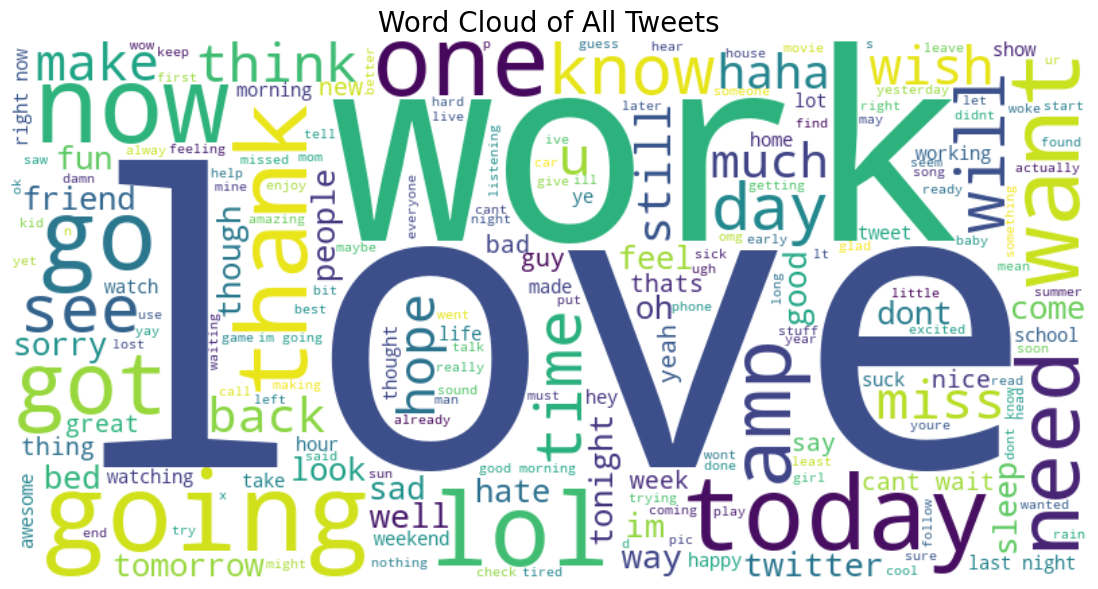

In [38]:
# Join all cleaned tweets into one big string
all_words = ' '.join(df['clean_text'])

# Create word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

# Display the image
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of All Tweets", fontsize=20)
plt.show()

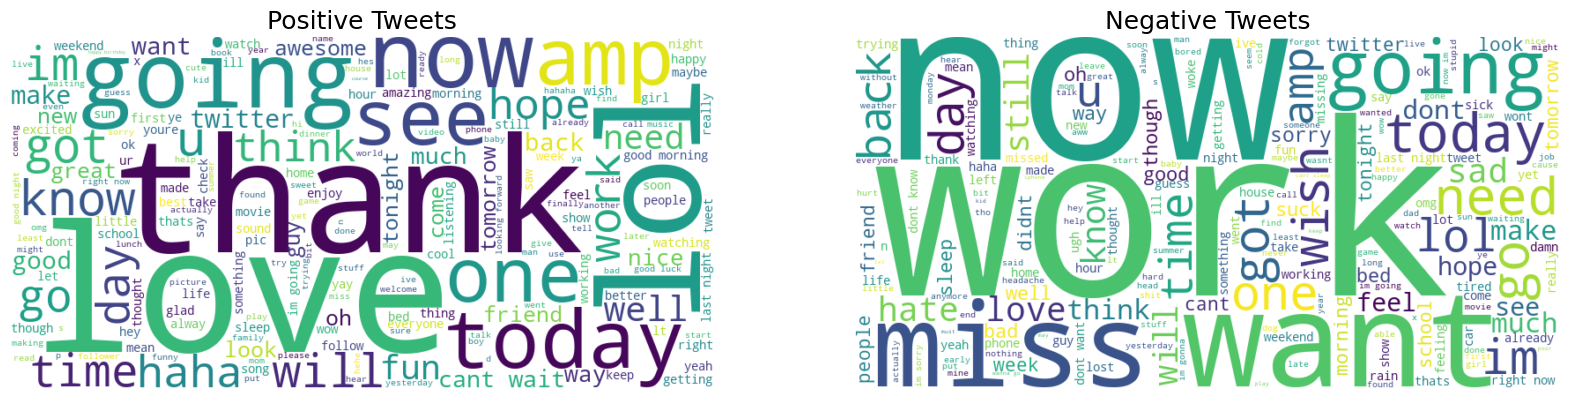

In [40]:
# Positive
pos_words = ' '.join(df[df['target'] == 4]['clean_text'])
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(pos_words)

# Negative
neg_words = ' '.join(df[df['target'] == 0]['clean_text'])
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(neg_words)

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title("Positive Tweets", fontsize=18)

axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title("Negative Tweets", fontsize=18)

plt.show()

In [56]:
# Tokenization & Text Vectorization. 
#Convert the cleaned text into a format a machine learning model can understand
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the data first
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_text'], df['target'], test_size=0.2, random_state=42, 
    stratify=df['target']
)

# initialize the vectorizer
vectorizer = TfidfVectorizer(max_features = 5000, stop_words ='english')


# Fit to training data
vectorizer.fit(X_train_text)

# transform
X_train = vectorizer.transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [54]:
print(f"Train features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

Train features shape: (1280000, 5000)
Test features shape: (320000, 5000)


In [58]:
# Train logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

#initialize the model
lr_model = LogisticRegression(max_iter =1000)

In [60]:
#fit to training data
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [62]:
#predict
y_pred = lr_model.predict(X_test)

In [64]:
# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.74      0.76    160000
           4       0.75      0.79      0.77    160000

    accuracy                           0.77    320000
   macro avg       0.77      0.77      0.77    320000
weighted avg       0.77      0.77      0.77    320000

Confusion Matrix:

[[118104  41896]
 [ 33080 126920]]


In [66]:
#Predict Sentiment of a New Tweet

In [134]:
def predict_sentiment_with_proba(tweet):
    cleaned = clean_tweet(tweet) #clean the tweet using previous clean_tweet function
    
    vectorized = vectorizer.transform([cleaned]) #vectorize using the trained vectorizer

    proba = lr_model.predict_proba(vectorized)[0] #prediction probability
    
    prediction = lr_model.predict(vectorized)[0] #Predict sentiment (0=neg, 4=pos)

    label = 'Positive' if prediction == 4 else 'negative' #Convert prediction to label

    confidence = proba[1] if prediction == 4 else proba[0] #confidence for predicted label
    
    return label, confidence

In [145]:
tweet1 = "I love how smooth this app works!"
tweet2 = "Worst update ever. Everything is broken."
tweet3 = "I can’t believe how bad this product turned out."
tweet4 = "I love how smooth this app works! Worst update ever, everything is broken."

In [138]:
predict_sentiment_with_proba(tweet3)

('negative', 0.7512845841295577)

In [140]:
predict_sentiment_with_proba(tweet1)

('Positive', 0.8838248739181629)

In [142]:
predict_sentiment_with_proba(tweet2)

('negative', 0.9877069042703631)

In [147]:
predict_sentiment_with_proba(tweet4)

('negative', 0.8024700200056822)